Dimensiones: (16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.00,16598.00,16598.00,16598.00,16598.00
mean,0.26,0.15,0.08,0.05,0.54
std,0.82,0.51,0.31,0.19,1.56
min,0.00,0.00,0.00,0.00,0.01
25%,0.00,0.00,0.00,0.00,0.06
50%,0.08,0.02,0.00,0.01,0.17
75%,0.24,0.11,0.04,0.04,0.47
max,41.49,29.02,10.22,10.57,82.74


,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
NA_Sales,1.00,0.77,0.45,0.63,0.94
EU_Sales,0.77,1.00,0.44,0.73,0.90
JP_Sales,0.45,0.44,1.00,0.29,0.61
Other_Sales,0.63,0.73,0.29,1.00,0.75
Global_Sales,0.94,0.90,0.61,0.75,1.00


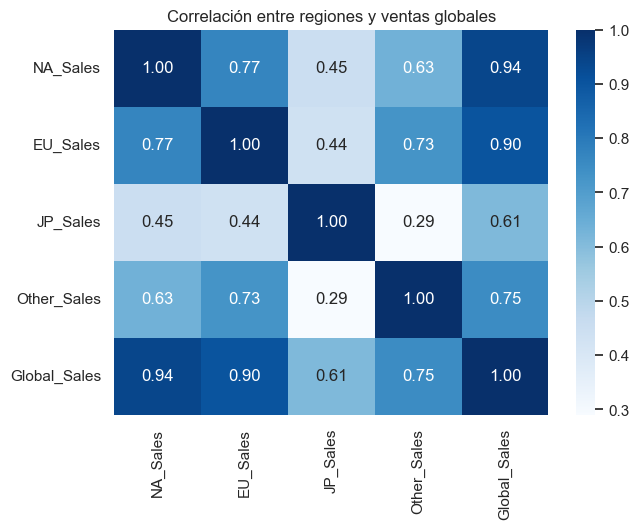

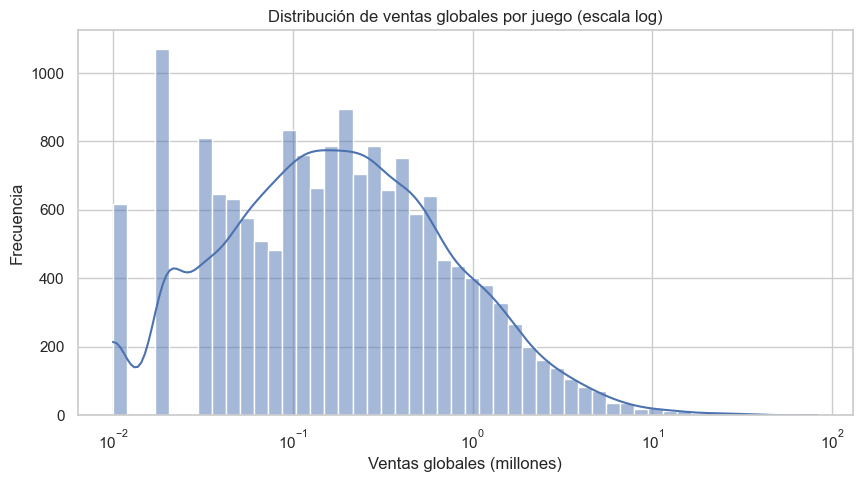

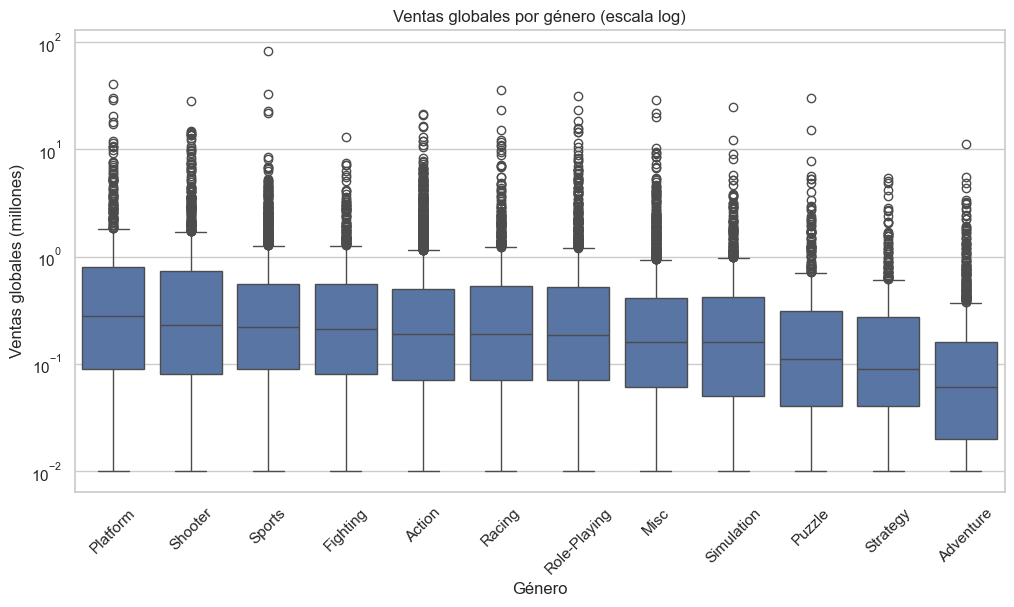

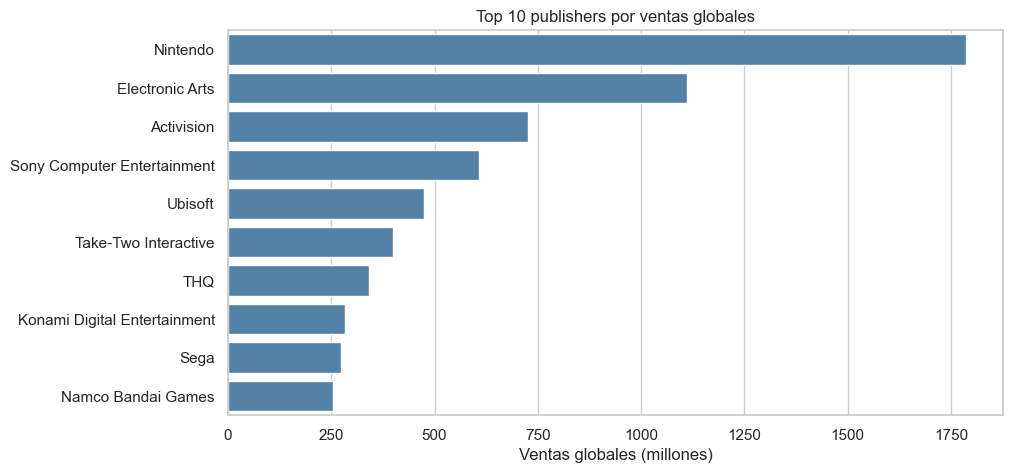

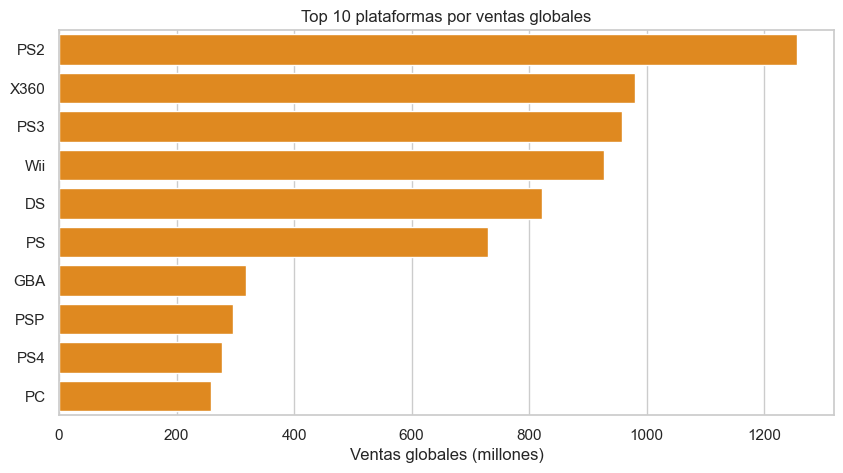

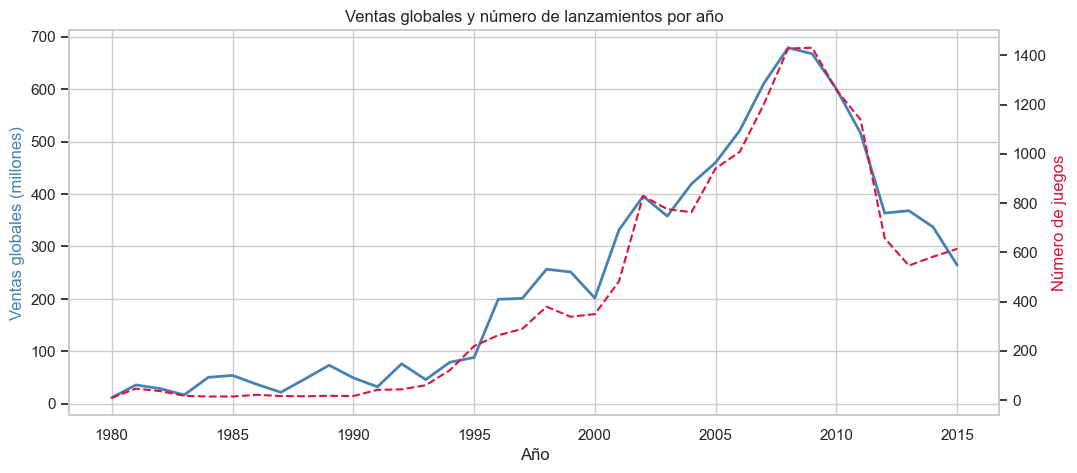

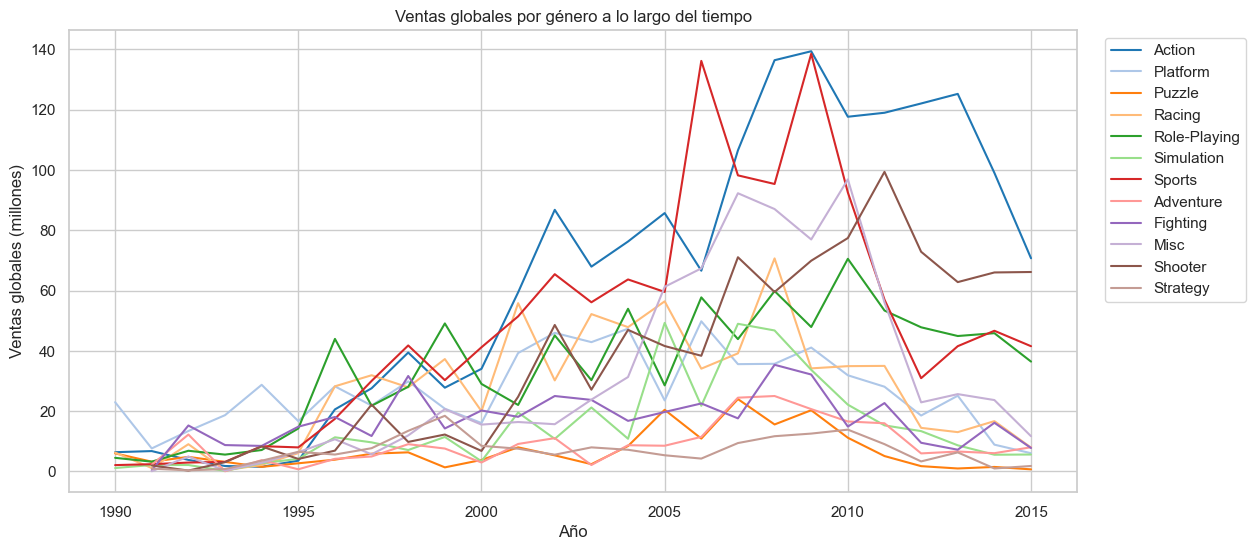

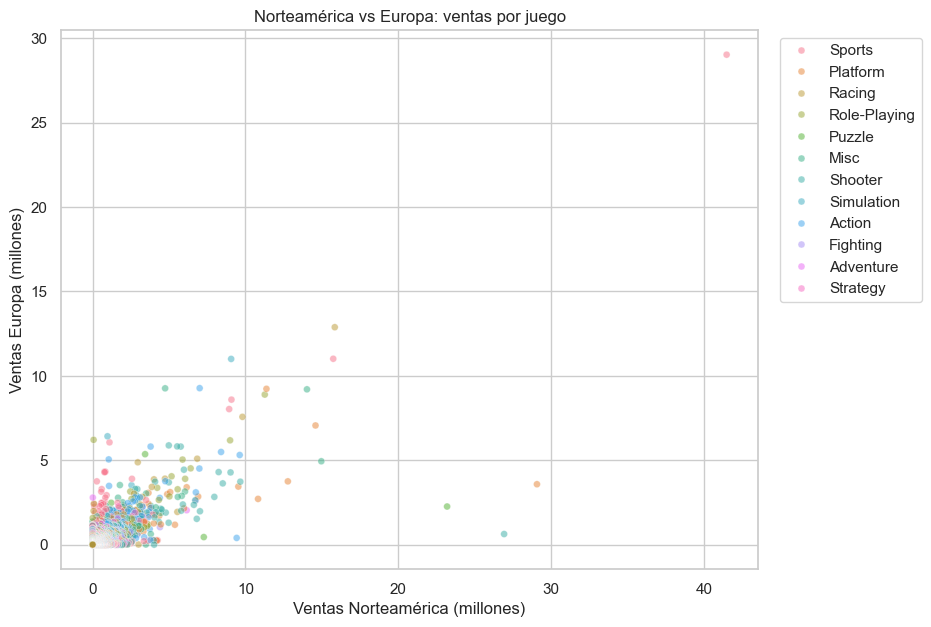

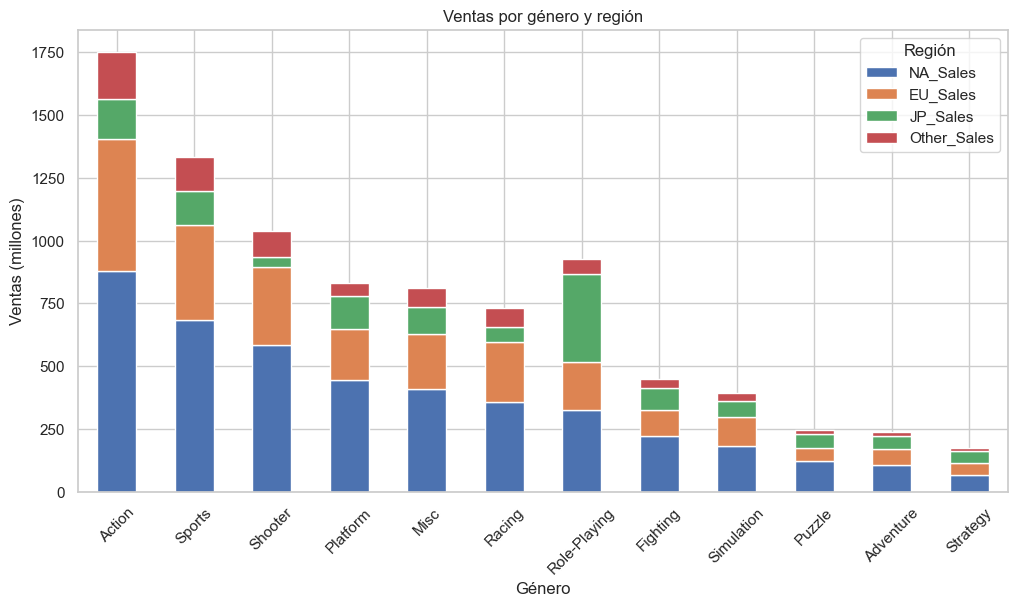

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,50.2,30.0,9.1,10.7
Sports,51.4,28.3,10.2,10.1
Shooter,56.2,30.2,3.7,9.9
Platform,53.8,24.3,15.7,6.2
Misc,50.7,26.7,13.3,9.3
Racing,49.1,32.6,7.7,10.6
Role-Playing,35.3,20.3,38.0,6.4
Fighting,49.8,22.6,19.5,8.2
Simulation,46.8,28.9,16.3,8.0


In [1]:
# # 02 - Análisis exploratorio (EDA) y visualizaciones

# %%
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

RAIZ = Path.cwd().parent
RUTA_DATOS = RAIZ / "data" / "vgsales.csv"
CARPETA_IMG = RAIZ / "images"
CARPETA_IMG.mkdir(exist_ok=True)

def guardar(nombre):
    """Guarda la gráfica actual en /images para usarla en el README."""
    plt.savefig(CARPETA_IMG / nombre, dpi=150, bbox_inches="tight")

# Carga y limpieza (los mismos pasos del notebook 01)
df = pd.read_csv(RUTA_DATOS)
for col in ["Name", "Platform", "Genre", "Publisher"]:
    df[col] = df[col].astype("string").str.strip()
df["Publisher"] = df["Publisher"].fillna("Unknown")
df["Year"] = df["Year"].astype("Int64")
df = df.drop_duplicates()

print("Dimensiones:", df.shape)
display(df.head())

# %%
# VARIABLES RELEVANTES: estadísticas y correlación
columnas_ventas = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"]

display(df[columnas_ventas].describe().round(2))

corr = df[columnas_ventas].corr()
display(corr.round(2))

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlación entre regiones y ventas globales")
guardar("01_correlacion.png")
plt.show()

# %% [markdown]
# ## Gráficos de distribución

# %%
# Histograma de ventas globales (escala logarítmica porque hay pocos éxitos enormes)
plt.figure(figsize=(10, 5))
sns.histplot(df["Global_Sales"], bins=50, kde=True, log_scale=True)
plt.title("Distribución de ventas globales por juego (escala log)")
plt.xlabel("Ventas globales (millones)")
plt.ylabel("Frecuencia")
guardar("02_histograma_ventas.png")
plt.show()

# Boxplot de ventas por género
orden_generos = df.groupby("Genre")["Global_Sales"].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Genre", y="Global_Sales", order=orden_generos)
plt.yscale("log")
plt.title("Ventas globales por género (escala log)")
plt.xlabel("Género")
plt.ylabel("Ventas globales (millones)")
plt.xticks(rotation=45)
guardar("03_boxplot_genero.png")
plt.show()

# %% [markdown]
# ## Rankings: top plataformas y publishers

# %%
top_publishers = (
    df.groupby("Publisher")["Global_Sales"].sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_publishers.values, y=top_publishers.index, color="steelblue")
plt.title("Top 10 publishers por ventas globales")
plt.xlabel("Ventas globales (millones)")
plt.ylabel("")
guardar("04_top_publishers.png")
plt.show()

top_plataformas = (
    df.groupby("Platform")["Global_Sales"].sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_plataformas.values, y=top_plataformas.index, color="darkorange")
plt.title("Top 10 plataformas por ventas globales")
plt.xlabel("Ventas globales (millones)")
plt.ylabel("")
guardar("05_top_plataformas.png")
plt.show()

# %% [markdown]
# ## Evolución en el tiempo

# %%
# Ventas y número de lanzamientos por año
# Se usa hasta 2015: 2016 en adelante tiene datos incompletos y parecería una caída falsa
df_tiempo = df.dropna(subset=["Year"]).copy()
df_tiempo["Year"] = df_tiempo["Year"].astype(int)
df_tiempo = df_tiempo[df_tiempo["Year"] <= 2015]

por_anio = df_tiempo.groupby("Year").agg(
    Ventas=("Global_Sales", "sum"),
    Lanzamientos=("Name", "count")
)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(por_anio.index, por_anio["Ventas"], color="steelblue", linewidth=2, label="Ventas globales")
ax1.set_xlabel("Año")
ax1.set_ylabel("Ventas globales (millones)", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(por_anio.index, por_anio["Lanzamientos"], color="crimson", linestyle="--", label="Lanzamientos")
ax2.set_ylabel("Número de juegos", color="crimson")
ax2.grid(False)

plt.title("Ventas globales y número de lanzamientos por año")
guardar("06_ventas_por_anio.png")
plt.show()

# Ventas por género a lo largo del tiempo
ventas_genero_anio = (
    df_tiempo[df_tiempo["Year"] >= 1990]
    .groupby(["Year", "Genre"])["Global_Sales"].sum()
    .reset_index()
)

plt.figure(figsize=(13, 6))
sns.lineplot(data=ventas_genero_anio, x="Year", y="Global_Sales", hue="Genre", palette="tab20")
plt.title("Ventas globales por género a lo largo del tiempo")
plt.xlabel("Año")
plt.ylabel("Ventas globales (millones)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
guardar("07_ventas_genero_tiempo.png")
plt.show()

# %% [markdown]
# ## Relaciones entre regiones

# %%
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df, x="NA_Sales", y="EU_Sales",
    hue="Genre", alpha=0.5, s=25
)
plt.title("Norteamérica vs Europa: ventas por juego")
plt.xlabel("Ventas Norteamérica (millones)")
plt.ylabel("Ventas Europa (millones)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
guardar("08_scatter_na_eu.png")
plt.show()

# %% [markdown]
# ## Barras apiladas: género y región

# %%
region_genero = (
    df.groupby("Genre")[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]]
    .sum()
    .sort_values("NA_Sales", ascending=False)
)

region_genero.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Ventas por género y región")
plt.xlabel("Género")
plt.ylabel("Ventas (millones)")
plt.xticks(rotation=45)
plt.legend(title="Región")
guardar("09_barras_apiladas_genero_region.png")
plt.show()

# Porcentaje de cada región dentro de cada género
region_genero_pct = region_genero.div(region_genero.sum(axis=1), axis=0) * 100
display(region_genero_pct.round(1))

# %% [markdown]
# ## Hallazgos
# Resume aquí con tus palabras los 3 o 4 hallazgos que más te llamaron la atención.